# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|  Rakha Makarim            |   5054251010    |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV

In [30]:
wine = pd.read_csv('WineQT.csv')

wine.info()
wine_duplicate = wine.duplicated().sum()
print("Number of duplicate rows: ", wine_duplicate)

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
Number of duplicate rows:  0


In [31]:
wine.drop(['Id'], axis=1, inplace=True)
wine.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

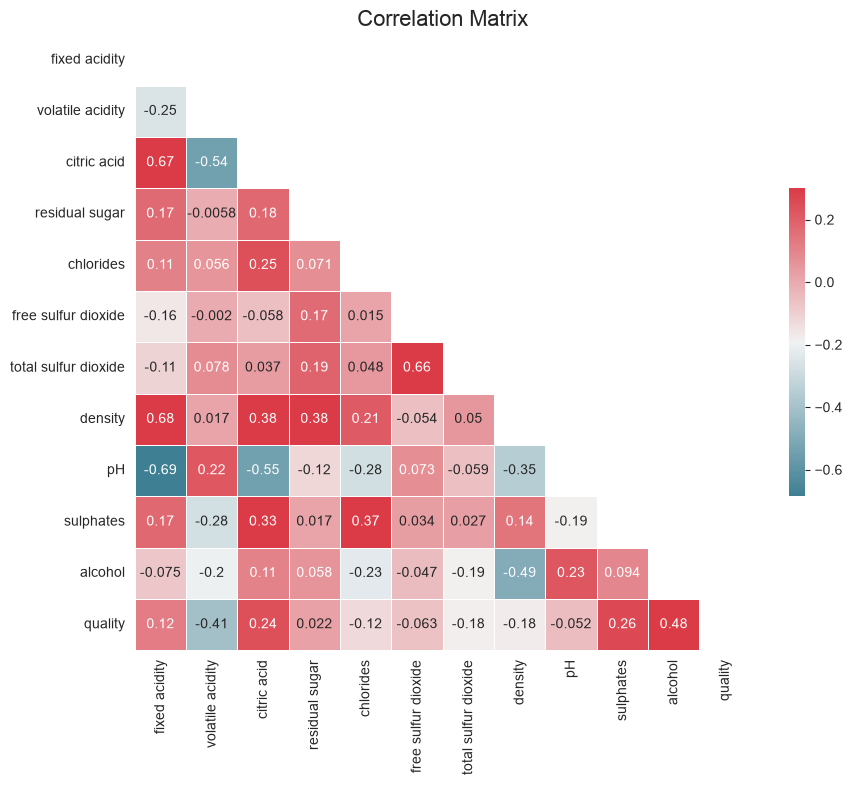

In [32]:
# Tampilkan Korelasi Matrix
corr = wine.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

cmap = sns.diverging_palette(220, 10, as_cmap=True)

with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(10, 8))
    ax = sns.heatmap(corr, cmap=cmap, mask=mask, vmax=.3, square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)
    plt.title('Correlation Matrix', fontsize=16)
    plt.show()

Di lihat dari corelasi matrix bahwa 'free sulfur dioxide', 'residual sugar', 'pH' memiliki nilai kedekatan hampir 0 dengan quality oleh karena itu kita bisa drop

In [33]:
wine.drop(['free sulfur dioxide', 'residual sugar', 'pH'], axis=1, inplace=True)

In [34]:
wine.head()

,fixed acidity,volatile acidity,citric acid,chlorides,total sulfur dioxide,density,sulphates,alcohol,quality
0,7.4,0.70,0.00,0.076,34.0,0.9978,0.56,9.4,5
1,7.8,0.88,0.00,0.098,67.0,0.9968,0.68,9.8,5
2,7.8,0.76,0.04,0.092,54.0,0.9970,0.65,9.8,5
3,11.2,0.28,0.56,0.075,60.0,0.9980,0.58,9.8,6
4,7.4,0.70,0.00,0.076,34.0,0.9978,0.56,9.4,5


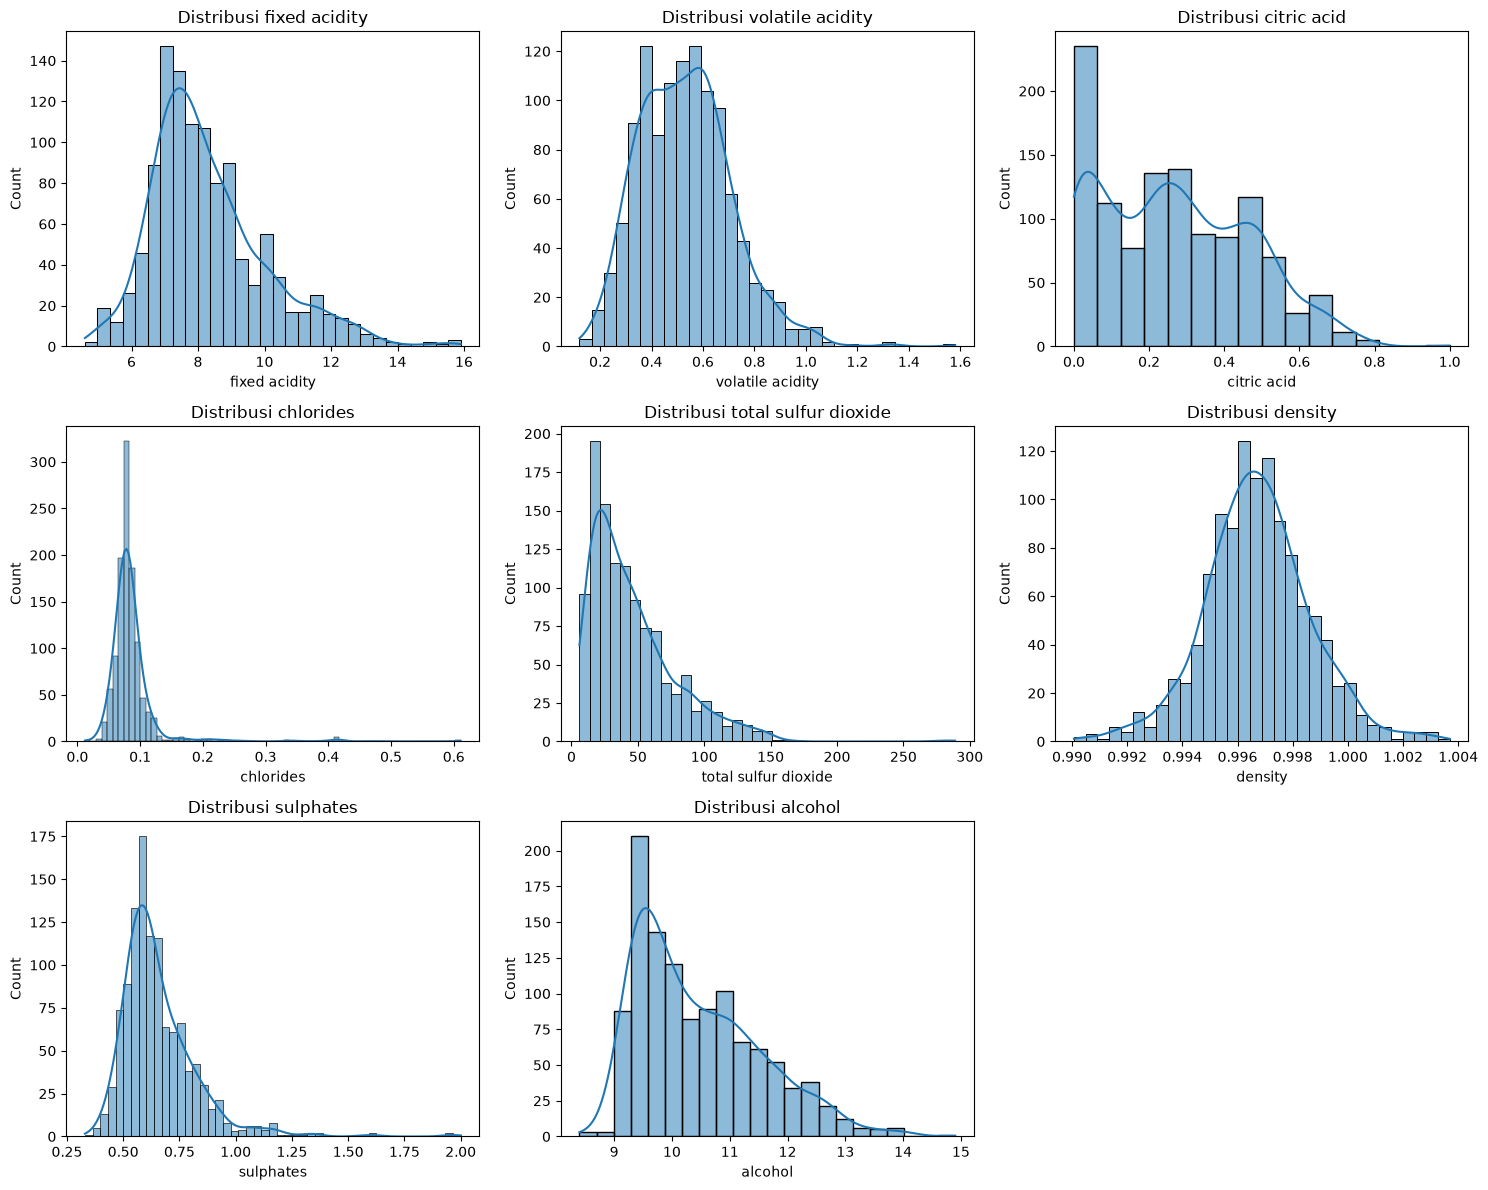

In [ ]:
feature_columns = wine.drop(columns=["quality"]).columns

n_cols = 3  
n_rows = int(np.ceil(len(feature_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, feature_columns):
    sns.histplot(wine[col], kde=True, ax=ax)
    ax.set_title(f"Distribusi {col}")

for ax in axes[len(feature_columns):]:
    ax.remove()

plt.tight_layout()
plt.show()

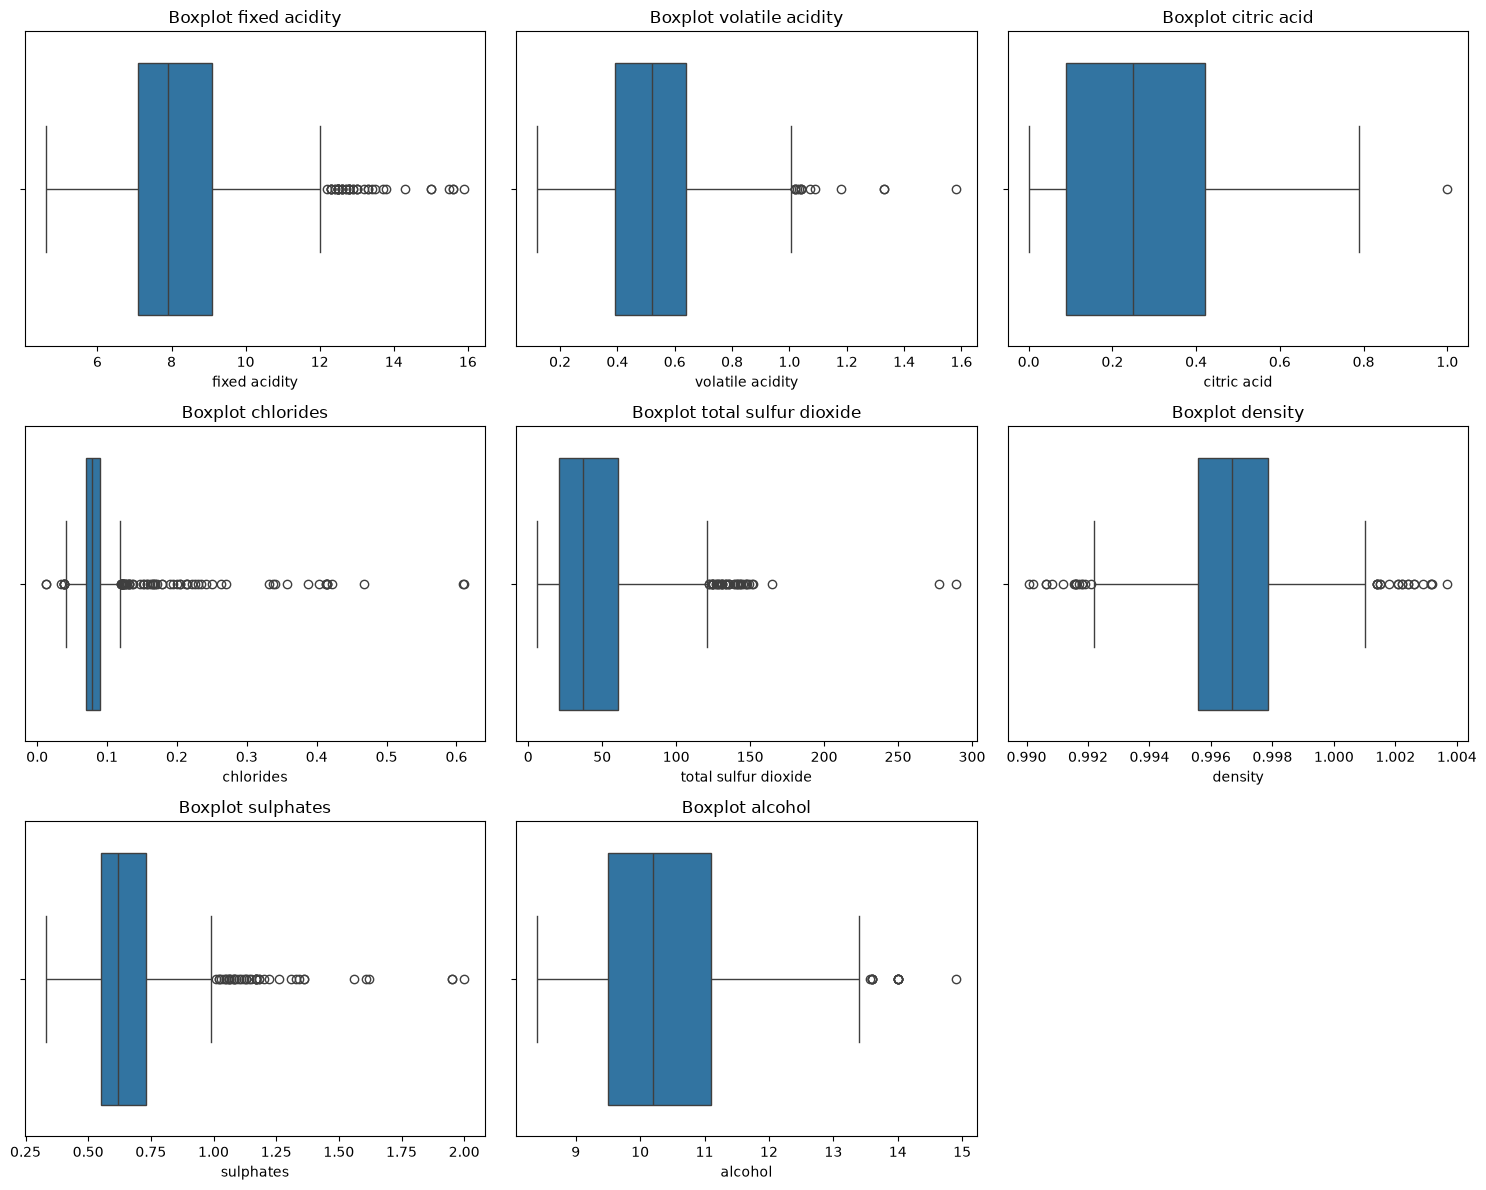

In [36]:
n_cols = 3
n_rows = int(np.ceil(len(feature_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, feature_columns):
    sns.boxplot(x=wine[col], ax=ax)
    ax.set_title(f"Boxplot {col}")

for ax in axes[len(feature_columns):]:
    ax.remove()

plt.tight_layout()
plt.show()

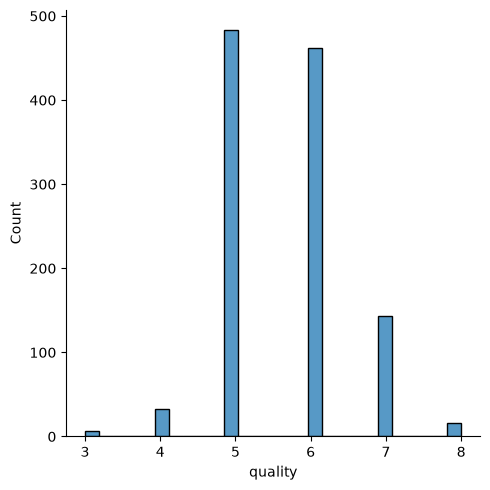

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

In [37]:
sns.displot(wine['quality'])
plt.show()
wine['quality'].value_counts()

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




In [38]:
X = wine.drop('quality', axis=1)
Y = wine['quality']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=11, stratify=Y)


In [39]:
def cap_outliers_train_test(train_df, test_df, columns, multiplier=1.5):
    train_df = train_df.copy()
    test_df = test_df.copy()

    for col in columns:
        Q1 = train_df[col].quantile(0.25)
        Q3 = train_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        train_df[col] = np.where(train_df[col] < lower_bound, lower_bound,
                                 np.where(train_df[col] > upper_bound, upper_bound, train_df[col]))
        test_df[col] = np.where(test_df[col] < lower_bound, lower_bound,
                                np.where(test_df[col] > upper_bound, upper_bound, test_df[col]))

        return train_df, test_df

In [40]:
numeric_features = X_train.columns
X_train_capped, X_test_capped = cap_outliers_train_test(X_train, X_test, numeric_features)

# 3. Eksperimen Model KNN


In [41]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

params = {
    'knn__n_neighbors': list(range(1,50,2)),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
    'scaler': [StandardScaler(), MinMaxScaler()]
}

In [50]:
grid_search = GridSearchCV(pipeline, params, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, Y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1-Macro saat tidak menggunakan capped data: {:.2f}".format(grid_search.best_score_))

Best parameters found:  {'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'distance', 'scaler': StandardScaler()}
Best cross-validation F1-Macro saat tidak menggunakan capped data: 0.38


In [51]:
grid_search = GridSearchCV(pipeline, params, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train_capped, Y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation F1-Macro saat menggunakan capped data: {:.2f}".format(grid_search.best_score_))

Best parameters found:  {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'distance', 'scaler': MinMaxScaler()}
Best cross-validation F1-Macro saat menggunakan capped data: 0.38


# 4. Evaluasi Model


## No capp

In [45]:
grid_search = GridSearchCV(pipeline, params, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, Y_train)
best_knn_model = grid_search.best_estimator_
y_pred = best_knn_model.predict(X_test)

print("Classification Report pada Data Test:")
print(classification_report(Y_test, y_pred, zero_division=0))


Classification Report pada Data Test:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.70      0.73      0.71        97
           6       0.55      0.59      0.57        92
           7       0.61      0.59      0.60        29
           8       0.00      0.00      0.00         3

    accuracy                           0.62       229
   macro avg       0.31      0.32      0.31       229
weighted avg       0.59      0.62      0.61       229



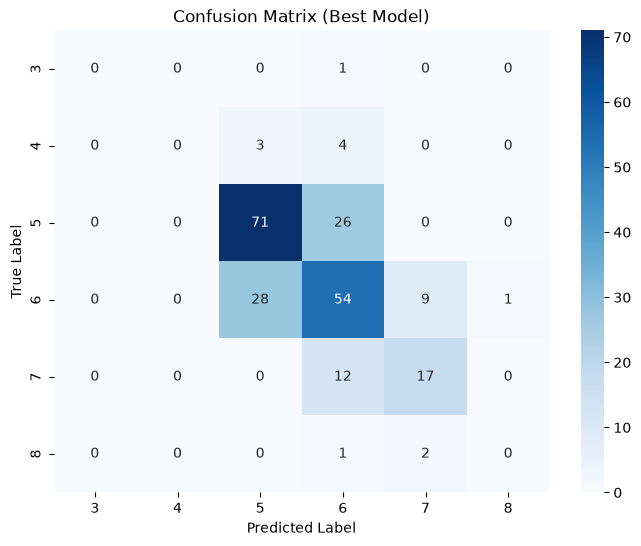

In [46]:
label_ = best_knn_model.classes_
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_, yticklabels=label_)
plt.title(f'Confusion Matrix (Best Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Pake Capp

In [47]:
grid_search = GridSearchCV(pipeline, params, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train_capped, Y_train)
best_knn_model = grid_search.best_estimator_
y_pred = best_knn_model.predict(X_test)

print("Classification Report pada Data Test:")
print(classification_report(Y_test, y_pred, zero_division=0))

Classification Report pada Data Test:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.76      0.73      0.74        97
           6       0.61      0.67      0.64        92
           7       0.53      0.59      0.56        29
           8       0.00      0.00      0.00         3

    accuracy                           0.66       229
   macro avg       0.32      0.33      0.32       229
weighted avg       0.63      0.66      0.64       229



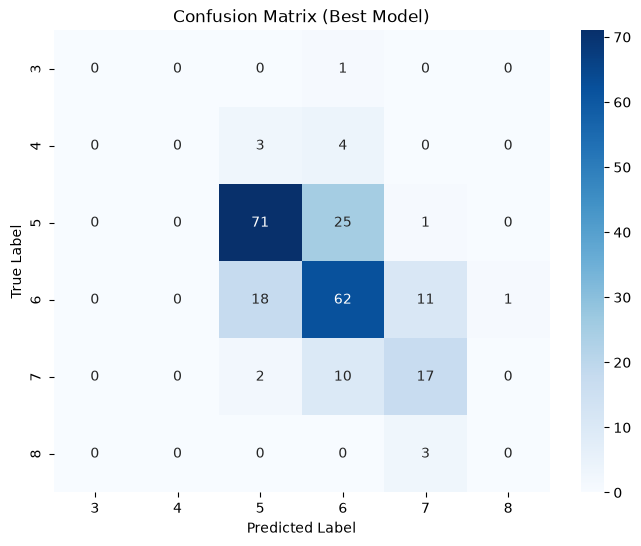

In [49]:
label_ = best_knn_model.classes_
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_, yticklabels=label_)
plt.title(f'Confusion Matrix (Best Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 5. Analisis

Problem : 
    1. Distribusi kelas target (quality) pada dataset Wine Quality bersifat imbalance (sangat didominasi oleh kelas mutu 5 dan 6).
    2. Meskipun metrik evaluasi seperti akurasi keseluruhan (accuracy) tampak tinggi, laporan klasifikasi memperlihatkan bahwa model mengalami kesulitan atau bahkan gagal mengenali kelas minoritas (mutu 3, 4, dan 8)

- Penggunaan StandardScaler dan MinMaxScaler memberikan performa yang optimal pada model KNN. Karena KNN sangat bergantung pada perhitungan jarak (Euclidean / Manhattan),
- Berdasarkan hasil pencarian parameter terbaik via GridSearchCV, kombinasi metrik terbaik merupakan manhattan di saat data di cap sedangkan euclidean saat tidak di capp
- Best parameter : 
    1. No capp = 'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'distance', 'scaler': StandardScaler()
    2. Capp    = 'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'distance', 'scaler': MinMaxScaler()
- saat di ukur dengan matrix f1-macro no capp data ataupun capp data bisa dikatan mirip tapi untuk nilai accuracy capp data lebih tinggi dibandingkan dengan no capp data.


# 6. Kesimpulan dan Saran


SARAN : 
    - Penerapan Teknik Resampling (SMOTE): Untuk mengatasi masalah class imbalance secara langsung, disarankan untuk mengintegrasikan teknik oversampling seperti SMOTE di dalam pipeline pelatihan agar model memiliki jumlah sampel yang seimbang untuk setiap kelas mutu wine.
    - Pengelompokan Kelas (Binning): Pertimbangkan untuk menyederhanakan target kelas menjadi 3 kategori utama (Contoh: Buruk: 3-4, Sedang: 5-6, Baik: 7-8).

Kesimpulan : 
    - Pengaruh Preprocessing: Pembersihan data melalui capping (IQR) serta penerapan penskalaan (StandardScaler atau MinMaxScaler) sangat krusial untuk mencegah distorsi pada perhitungan jarak antar-sampel di dalam algoritma KNN.
    - Evaluasi Data Imbalance: Penggunaan metrik evaluasi F1-Macro memberikan gambaran performa yang jauh lebih objektif dibandingkan akurasi biasa, mengingat karakteristik dataset Wine Quality yang tidak seimbang pada berbagai kelas mutu wine.